# 02 — Preprocessing
## Malaria Cell Classification Using Deep Learning

**Project:** Malaria Cell Classification Using Deep Learning
**Author:** Kepha | Data Science Capstone Project in Collaboration with Ngao Labs

### Purpose of this notebook
Turn the raw, variably-sized NIH/NLM cell crops (indexed and validated in `01_eda.ipynb`) into
model-ready inputs for both the Logistic Regression baseline and the EfficientNetB0 transfer-learning
model, and persist every artefact needed downstream so `03_modelling.ipynb` never has to touch
`data/raw/` directly.

### What this notebook produces (in `data/processed/`)
| Artefact | Purpose |
|---|---|
| `splits/train.csv`, `val.csv`, `test.csv` | Stratified file-path/label splits — the single source of truth for every downstream notebook |
| `baseline/train_features.npy` (+ val/test) | HOG + colour-histogram feature vectors for the Logistic Regression baseline |
| `baseline/train_labels.npy` (+ val/test) | Corresponding labels for the baseline features |
| `preprocessing_config.json` | Every constant (image size, batch size, seed, class mapping) used here, re-loaded by later notebooks |

### Design principles
- **Deterministic:** a single `RANDOM_SEED` drives every split and sample so results are reproducible.
- **Source data stays untouched:** everything derived is written to `data/processed/`, never back to `data/raw/`.
- **Two parallel tracks:** classical HOG/colour features for the baseline vs. `tf.data` image pipelines
  for the deep model — built once here, re-used everywhere else.
- **Efficient by construction:** vectorized feature extraction, `tf.data` with `cache()`/`prefetch()`,
  and augmentation applied only to the training split, not pre-baked to disk.


In [2]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# Core libraries
import os
import json
import random
import warnings
import zipfile

import numpy as np
import pandas as pd

# Image handling
from PIL import Image
import cv2

# Preprocessing / splitting
from sklearn.model_selection import train_test_split

# Deep learning preprocessing utilities
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.applications.efficientnet import preprocess_input

# Baseline feature extraction
from skimage.feature import hog

# Visualization (sanity checks only)
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=UserWarning)

RANDOM_SEED = 42
IMG_SIZE = (224, 224)         # EfficientNetB0 native input size
BATCH_SIZE = 32

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

print("TensorFlow:", tf.__version__)
print("GPU available:", bool(tf.config.list_physical_devices("GPU")))


TensorFlow: 2.20.0
GPU available: False


## 1. Configuration & Path Resolution

`resolve_data_dir` guards against the double-nested-folder issue commonly seen with this Kaggle
archive (`cell_images/cell_images/Parasitized/...`) by checking both the given path and one level
deeper, and failing loudly with a clear error rather than silently indexing zero images.


In [4]:
#RAW_DIR = "/content/drive/MyDrive/capstone-project/data/raw/cell_images"
#PROCESSED_DIR = "/content/drive/MyDrive/capstone-project/data/processed"

In [5]:
zip_path = "/content/drive/MyDrive/capstone-project/data/raw/data.zip"
extract_path = "/content/malaria_data"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction completed.")

Extraction completed.


In [6]:
RAW_DIR = os.path.join(extract_path, "cell_images")
PROCESSED_DIR = "/content/drive/MyDrive/capstone-project/data/processed"
CLASS_FOLDERS = {"Parasitized": 1, "Uninfected": 0}   # folder name -> label

SPLIT_DIR = os.path.join(PROCESSED_DIR, "splits")
BASELINE_DIR = os.path.join(PROCESSED_DIR, "baseline")
for d in (SPLIT_DIR, BASELINE_DIR):
    os.makedirs(d, exist_ok=True)


def resolve_data_dir(base_dir, required=("Parasitized", "Uninfected")):
    """Return the directory that directly contains the class subfolders,
    checking one extra level of nesting before failing."""
    candidates = [base_dir, os.path.join(base_dir, "cell_images")]
    for c in candidates:
        if os.path.isdir(c) and all(os.path.isdir(os.path.join(c, s)) for s in required):
            return c
    raise FileNotFoundError(
        f"Could not find {required} under '{base_dir}' or '{base_dir}/cell_images'. "
        f"Check RAW_DIR and your folder structure."
    )


DATA_DIR = resolve_data_dir(RAW_DIR)
print("Resolved data directory:", os.path.abspath(DATA_DIR))


Resolved data directory: /content/malaria_data/cell_images


## 2. File Index

Rebuilds the same `filepath` / `label` / `class_name` index used in `01_eda.ipynb`. Kept
self-contained here (rather than imported) so this notebook can be run independently.


In [7]:
records = []
for folder, label in CLASS_FOLDERS.items():
    folder_path = os.path.join(DATA_DIR, folder)
    filepaths = [os.path.join(folder_path, f) for f in os.listdir(folder_path) if f.lower().endswith(".png")]
    records.extend([(fp, label, folder) for fp in filepaths])

df = pd.DataFrame(records, columns=["filepath", "label", "class_name"])
assert len(df) > 0, "File index is empty — check DATA_DIR before continuing."
print(f"Total images indexed: {len(df):,}")
df["label"].value_counts()


Total images indexed: 27,558


,count
label,
1,13779
0,13779


## 3. Train / Validation / Test Split

An **80 / 10 / 10** stratified split, preserving class balance in every subset. Splitting is done
once here and persisted to CSV so every later notebook (modelling, evaluation) references the exact
same rows — no risk of train/test leakage from re-splitting with a different seed.


In [8]:
train_df, temp_df = train_test_split(
    df, test_size=0.20, stratify=df["label"], random_state=RANDOM_SEED
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df["label"], random_state=RANDOM_SEED
)

for name, split in [("train", train_df), ("val", val_df), ("test", test_df)]:
    split.to_csv(os.path.join(SPLIT_DIR, f"{name}.csv"), index=False)

split_summary = pd.DataFrame({
    "split": ["train", "val", "test"],
    "n_images": [len(train_df), len(val_df), len(test_df)],
    "pct_parasitized": [
        d["label"].mean() * 100 for d in (train_df, val_df, test_df)
    ],
})
print(split_summary.to_string(index=False))
print(f"\nSplits written to: {os.path.abspath(SPLIT_DIR)}")


split  n_images  pct_parasitized
train     22046             50.0
  val      2756             50.0
 test      2756             50.0

Splits written to: /content/drive/MyDrive/capstone-project/data/processed/splits


## 4. Baseline Features — HOG + Colour Histogram

The Logistic Regression baseline needs fixed-length, hand-crafted feature vectors rather than raw
pixels. Each image is:
1. Resized to a small, fixed size (`64×64`) — sufficient for HOG texture features without the
   computational cost of full resolution.
2. Converted to grayscale for **HOG** (captures the parasite's edge/texture signature).
3. Kept in colour to compute a per-channel **colour histogram** (captures the Giemsa-stain signal
   identified in the EDA's colour-channel analysis).
4. Concatenated into a single feature vector per image.

Extraction is vectorized per-image via a single function and looped once per split (not repeated
across notebooks), with the resulting arrays persisted to disk.


In [9]:
BASELINE_IMG_SIZE = (64, 64)
HIST_BINS = 32


def extract_baseline_features(filepath):
    """Return a concatenated HOG + RGB colour-histogram feature vector for one image."""
    img = cv2.imread(filepath)
    img = cv2.resize(img, BASELINE_IMG_SIZE)

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    hog_features = hog(
        gray,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm="L2-Hys",
    )

    hist_features = np.concatenate([
        cv2.calcHist([img], [c], None, [HIST_BINS], [0, 256]).flatten()
        for c in range(3)
    ])
    hist_features = hist_features / (hist_features.sum() + 1e-8)   # normalize to proportions

    return np.concatenate([hog_features, hist_features]).astype(np.float32)


def build_feature_matrix(split_df, split_name):
    features = np.stack([extract_baseline_features(fp) for fp in split_df["filepath"]])
    labels = split_df["label"].to_numpy()

    np.save(os.path.join(BASELINE_DIR, f"{split_name}_features.npy"), features)
    np.save(os.path.join(BASELINE_DIR, f"{split_name}_labels.npy"), labels)

    print(f"{split_name}: features {features.shape}, labels {labels.shape}")
    return features, labels


X_train, y_train = build_feature_matrix(train_df, "train")
X_val, y_val = build_feature_matrix(val_df, "val")
X_test, y_test = build_feature_matrix(test_df, "test")


train: features (22046, 1860), labels (22046,)
val: features (2756, 1860), labels (2756,)
test: features (2756, 1860), labels (2756,)


## 5. Deep Learning Input Pipeline — `tf.data`

Rather than materializing 27,558 resized images to disk (duplicating storage), image loading,
decoding, and resizing are wrapped in a `tf.data.Dataset` pipeline built directly from the split
CSVs. This is:
- **Lazy** — images are only decoded when a batch is requested.
- **Reusable** — `03_modelling.ipynb` calls `make_dataset()` again from the same CSVs; nothing here
  needs to be re-run if the kernel restarts.
- **Memory-safe** — `.cache()` with no filename caches the *entire decoded dataset in RAM*. At
  224×224×3 float32, ~27,558 images would need roughly 16.5 GB of RAM — more than a standard Colab
  runtime provides, and enough to crash a modest local machine too. To avoid this:
  1. The cache stores images as **`uint8`** (raw pixel values), not `float32` — a 4x reduction.
  2. EfficientNet's `preprocess_input` scaling is applied **after** the cache, as a separate cheap
     map step, so the expensive part (decode + resize) is what gets cached, not the final tensor.
  3. The cache is written to **local disk** (`cache_path`), not RAM — trading a small amount of
     one-time disk I/O for a pipeline that can't OOM.

Augmentation (random flip, rotation, and colour jitter — informed by the staining variation seen in
EDA) is applied **only to the training split**, via Keras preprocessing layers so it runs on-GPU as
part of the model graph rather than as a CPU bottleneck.


In [10]:
AUTOTUNE = tf.data.AUTOTUNE
CACHE_DIR = "/content/drive/MyDrive/capstone-project/data/processed/tfcache"
os.makedirs(CACHE_DIR, exist_ok=True)
#CACHE_DIR = "/content/tfcache" if os.path.exists("/content") else "./tfcache"   # local disk, not Drive
#os.makedirs(CACHE_DIR, exist_ok=True)


def decode_and_resize(filepath, label):
    """Decode + resize only. Kept as uint8 so the on-disk cache stays small (4x smaller than float32)."""
    image = tf.io.read_file(filepath)
    image = tf.image.decode_png(image, channels=3)
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.uint8)
    return image, label


def apply_efficientnet_scaling(image, label):
    """Cheap per-batch step, applied after caching so the cache doesn't store float32 tensors."""
    image = preprocess_input(tf.cast(image, tf.float32))
    return image, label


def make_dataset(split_df, training, split_name, batch_size=BATCH_SIZE):
    filepaths = split_df["filepath"].to_numpy()
    labels = split_df["label"].to_numpy()

    ds = tf.data.Dataset.from_tensor_slices((filepaths, labels))
    ds = ds.map(decode_and_resize, num_parallel_calls=AUTOTUNE)
    ds = ds.cache(os.path.join(CACHE_DIR, split_name))   # disk-based cache, not in-memory

    if training:
        ds = ds.shuffle(buffer_size=len(split_df), seed=RANDOM_SEED)

    ds = ds.map(apply_efficientnet_scaling, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size)
    ds = ds.prefetch(AUTOTUNE)
    return ds


train_ds = make_dataset(train_df, training=True, split_name="train")
val_ds = make_dataset(val_df, training=False, split_name="val")
test_ds = make_dataset(test_df, training=False, split_name="test")

for images, labels in train_ds.take(1):
    print("Batch image shape:", images.shape)
    print("Batch label shape:", labels.shape)


Batch image shape: (32, 224, 224, 3)
Batch label shape: (32,)


In [11]:
# Augmentation layer — applied inside the model graph during training only (03_modelling.ipynb
# calls `augmentation(images, training=True)` as the model's first layer). Defined here so the
# augmentation policy lives alongside the rest of the preprocessing decisions.
augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical", seed=RANDOM_SEED),
    layers.RandomRotation(0.1, seed=RANDOM_SEED),
    layers.RandomContrast(0.1, seed=RANDOM_SEED),
], name="augmentation")

augmentation.summary()


Model: "augmentation"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ ?                      │   0 (unbuilt) │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast                 │ ?                      │   0 (unbuilt) │
│ (RandomContrast)                │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## 6. Sanity Check — Augmented Batch

A quick visual check that the augmentation pipeline produces varied, non-degenerate images before
this is handed off to modelling.


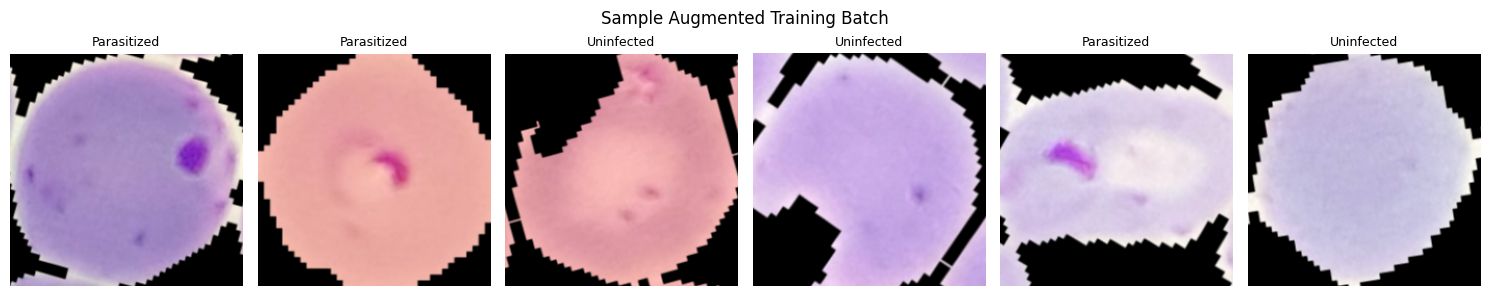

In [12]:
for images, labels in train_ds.take(1):
    augmented = augmentation(images, training=True)

    fig, axes = plt.subplots(1, 6, figsize=(15, 3))
    for i, ax in enumerate(axes):
        # undo EfficientNet preprocessing just for display purposes
        display_img = augmented[i].numpy() - augmented[i].numpy().min()
        display_img = display_img / (display_img.max() + 1e-8)
        ax.imshow(display_img)
        ax.set_title("Parasitized" if labels[i].numpy() == 1 else "Uninfected", fontsize=9)
        ax.axis("off")
    plt.suptitle("Sample Augmented Training Batch")
    plt.tight_layout()
    plt.show()


## 7. Persist Pipeline Configuration

Saves the exact preprocessing constants used here (image size, batch size, seed, class mapping) to
`data/processed/preprocessing_config.json`, so `03_modelling.ipynb` and `04_evaluation.ipynb` load
these values rather than risking silent drift from re-typed constants.


In [13]:
config = {
    "random_seed": RANDOM_SEED,
    "img_size": list(IMG_SIZE),
    "batch_size": BATCH_SIZE,
    "class_folders": CLASS_FOLDERS,
    "baseline_img_size": list(BASELINE_IMG_SIZE),
    "baseline_hist_bins": HIST_BINS,
    "data_dir": os.path.abspath(DATA_DIR),
    "split_dir": os.path.abspath(SPLIT_DIR),
    "baseline_dir": os.path.abspath(BASELINE_DIR),
}

config_path = os.path.join(PROCESSED_DIR, "preprocessing_config.json")
with open(config_path, "w") as f:
    json.dump(config, f, indent=2)

print(f"Config saved to: {os.path.abspath(config_path)}")
config


Config saved to: /content/drive/MyDrive/capstone-project/data/processed/preprocessing_config.json


{'random_seed': 42,
 'img_size': [224, 224],
 'batch_size': 32,
 'class_folders': {'Parasitized': 1, 'Uninfected': 0},
 'baseline_img_size': [64, 64],
 'baseline_hist_bins': 32,
 'data_dir': '/content/malaria_data/cell_images',
 'split_dir': '/content/drive/MyDrive/capstone-project/data/processed/splits',
 'baseline_dir': '/content/drive/MyDrive/capstone-project/data/processed/baseline'}

## 8. Summary & Next Steps

**Artefacts written to `data/processed/`:**
- `splits/{train,val,test}.csv` — stratified 80/10/10 file-path/label splits
- `baseline/{train,val,test}_features.npy` + `_labels.npy` — HOG + colour-histogram vectors for the
  Logistic Regression baseline
- `preprocessing_config.json` — every constant needed to reproduce this notebook's pipeline exactly

**Carried forward to `03_modelling.ipynb`:**
- Load `X_train` / `X_val` / `X_test` (baseline features) directly from the saved `.npy` files to fit
  and tune the Logistic Regression baseline.
- Rebuild `train_ds` / `val_ds` / `test_ds` from the saved split CSVs using the same `make_dataset()`
  logic, and apply the saved `augmentation` layer as the first layer of the EfficientNetB0 model.
- Decision-threshold tuning and Grad-CAM both operate on this same `tf.data` pipeline, so no further
  preprocessing changes should be needed downstream.
